In [1]:
import numpy as np
import matplotlib . pyplot as plt
import os
from matplotlib.colors import LogNorm
import seaborn as sns

In [2]:
np. random . seed (2025)
n, p, k = 500 , 50, 8
sigma = 1.0

m = 10
Z = np. random . randn (n, m)
A = np. random . randn (m, p) * 0.8
X = Z.dot(A) + 0.1 * np. random . randn (n, p)

w_true = np. zeros (p)
w_true [:k] = np. linspace (5.0 , 1.0 , k) * np. random . choice ([1 , -1], k)
y = X.dot( w_true ) + sigma * np. random . randn (n)

idx = np. random . permutation (n)
train_idx , test_idx = idx [:350] , idx [350:]
X_train , y_train = X[ train_idx ], y[ train_idx ]
X_test , y_test = X[ test_idx ], y[ test_idx ]

def ridge_closed_form (X, y, lam):
    n_features = X.shape[1]
    I = np.eye(n_features)
    w = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y
    return w

def ridge_objective (X, y, w, lam):
    residual = X @ w - y
    return np.dot(residual, residual) + lam * np.dot(w, w)
    

def ridge_grad (X, y, w, lam):
    return 2 * (X.T @ (X @ w - y) + lam * w)

def gradient_descent (X, y, lam , s, alpha , beta ):
    w = np.zeros(X.shape[1])
    obj_values = []

    for _ in range(1000):
        grad = ridge_grad(X, y, w, lam)
        t = s
        # Armijo condition
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta  # shrink step size
        w = w - t * grad
        obj_values.append(ridge_objective(X, y, w, lam))
    return w, obj_values

In [3]:
def gradient_descent_with_path(X, y, lam, s, alpha, beta, max_iter=2000):
    w = np.zeros(X.shape[1])
    path = [w.copy()]   # store iterates

    for k in range(max_iter):
        grad = ridge_grad(X, y, w, lam)
        t = s

        # Armijo line search
        while ridge_objective(X, y, w - t*grad, lam) > \
              ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta

        w = w - t * grad
        path.append(w.copy())
    
    return w, np.array(path)

In [4]:

def plot_contours_with_path(X, y, lam, path, levels=30):

    # grid limits from the path
    w1_vals = np.linspace(path[:,0].min()-1, path[:,0].max()+1, 200)
    w2_vals = np.linspace(path[:,1].min()-1, path[:,1].max()+1, 200)

    W1, W2 = np.meshgrid(w1_vals, w2_vals)
    Z = np.zeros_like(W1)

    # compute objective at each grid point
    for i in range(W1.shape[0]):
        for j in range(W1.shape[1]):
            w = np.array([W1[i, j], W2[i, j]])
            Z[i, j] = ridge_objective(X, y, w, lam)

    plt.figure(figsize=(8, 6))

    # contour plot
    cs = plt.contour(W1, W2, Z, levels=levels, cmap='viridis')
    plt.clabel(cs, inline=True, fontsize=8)

    # plot iterates
    plt.plot(path[:,0], path[:,1], 'o-', color='red', markersize=4, label='Iterates')

    # mark start + end
    plt.scatter(path[0,0], path[0,1], color='blue', s=80, label='Start')
    plt.scatter(path[-1,0], path[-1,1], color='red', s=80, label='End')

    plt.xlabel('$w_1$')
    plt.ylabel('$w_2$')
    plt.title('Gradient Descent Iterates on Ridge Objective')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

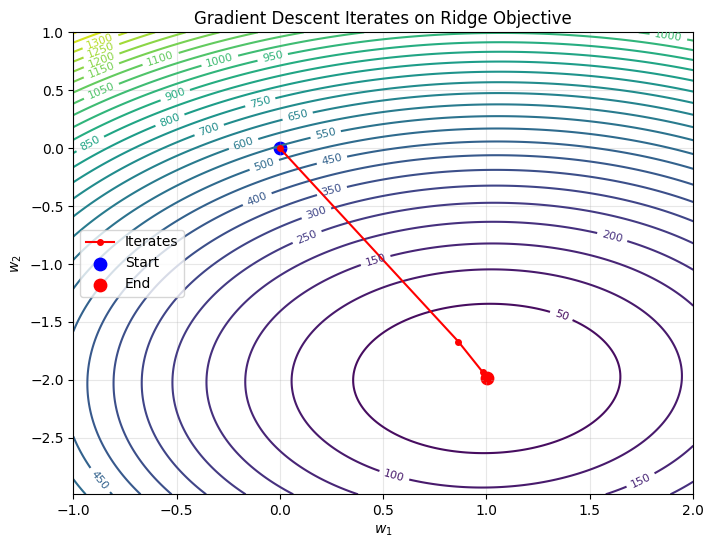

In [5]:
np.random.seed(0)
X = np.random.randn(100, 2)
true_w = np.array([1.0, -2.0])
y = X @ true_w + 0.1*np.random.randn(100)

lam = 1.0
s = 1.0
alpha = 0.25
beta = 0.5

w_final, path = gradient_descent_with_path(X, y, lam, s, alpha, beta)

plot_contours_with_path(X, y, lam, path)

In [6]:
def gradient_descent_with_path(X, y, lam, s, alpha, beta, max_iter=2000):
    w = np.zeros(X.shape[1])
    path = [w.copy()]

    for k in range(max_iter):
        grad = ridge_grad(X, y, w, lam)
        t = s

        # Armijo line search
        while ridge_objective(X, y, w - t*grad, lam) > \
              ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta

        w = w - t * grad
        path.append(w.copy())

    return w, np.array(path)

In [7]:
def plot_contours_with_path(X, y, lam, path, levels=30):
    # project iterates onto first two coordinates
    path2d = path[:, :2]

    # Create contour grid
    w1_vals = np.linspace(path2d[:,0].min() - 2, path2d[:,0].max() + 2, 200)
    w2_vals = np.linspace(path2d[:,1].min() - 2, path2d[:,1].max() + 2, 200)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)
    Z = np.zeros_like(W1)

    # Evaluate objective on-plane (w3..w50 = 0)
    for i in range(W1.shape[0]):
        for j in range(W1.shape[1]):
            w = np.zeros(X.shape[1])
            w[0] = W1[i, j]
            w[1] = W2[i, j]
            Z[i, j] = ridge_objective(X, y, w, lam)

    # Plot contours
    plt.figure(figsize=(8, 6))
    cs = plt.contour(W1, W2, Z, levels=levels, cmap='viridis')
    plt.clabel(cs, inline=True, fontsize=7)

    # Plot iterate path
    plt.plot(path2d[:,0], path2d[:,1], 'o-', color='red', markersize=4, label='GD iterates')

    # Start/end markers
    plt.scatter(path2d[0,0], path2d[0,1], s=80, color='blue', label="Start")
    plt.scatter(path2d[-1,0], path2d[-1,1], s=80, color='red', label="End")

    plt.xlabel("$w_1$")
    plt.ylabel("$w_2$")
    plt.title("Gradient Descent Iterates on 50D Ridge Objective (Projected to $w_1$–$w_2$)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

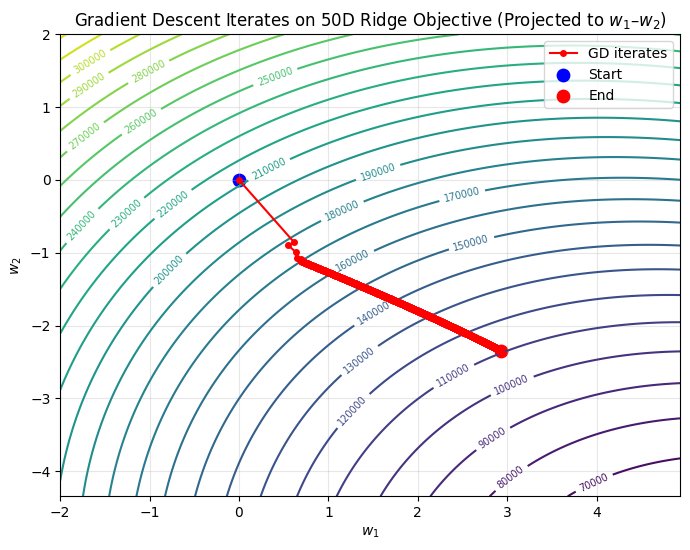

In [8]:
lam = 1.0
s = 1.0
alpha = 0.25
beta = 0.5

w_final, path = gradient_descent_with_path(X_train, y_train, lam, s, alpha, beta)
plot_contours_with_path(X_train, y_train, lam, path)

In [16]:
def gd_fixed_step_with_path(X, y, lam, eta, max_iter=300):
    w = np.zeros(X.shape[1])
    path = [w.copy()]

    for k in range(max_iter):
        grad = ridge_grad(X, y, w, lam)
        w = w - eta * grad
        path.append(w.copy())
    
    return w, np.array(path)

In [12]:
def pca_numpy(X, k=2):
    # center
    Xc = X - X.mean(axis=0)

    # SVD
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

    # projection and reconstruction operators
    components = Vt[:k]                 # shape (k, d)
    proj = Xc @ components.T            # shape (n, k)

    return proj, components, X.mean(axis=0)

In [13]:
proj, components, mean_vec = pca_numpy(path, 2)

def pca_inverse_transform(u, components, mean_vec):
    return mean_vec + u @ components

In [14]:
def plot_zigzag_contours_np_pca(X, y, lam, path, proj, components, mean_vec, levels=40):
    u = proj  # path in 2D

    u1_vals = np.linspace(u[:,0].min()-1, u[:,0].max()+1, 200)
    u2_vals = np.linspace(u[:,1].min()-1, u[:,1].max()+1, 200)
    U1, U2 = np.meshgrid(u1_vals, u2_vals)
    Z = np.zeros_like(U1)

    # compute objective on PCA plane
    for i in range(U1.shape[0]):
        for j in range(U1.shape[1]):
            u_point = np.array([U1[i,j], U2[i,j]])
            w_point = pca_inverse_transform(u_point, components, mean_vec)
            Z[i,j] = ridge_objective(X, y, w_point, lam)

    # plotting
    plt.figure(figsize=(8,6))
    cs = plt.contour(U1, U2, Z, levels=levels, cmap='viridis')
    plt.clabel(cs, inline=True, fontsize=7)

    # zigzag path
    plt.plot(u[:,0], u[:,1], 'o-', color='red', markersize=3)

    plt.scatter(u[0,0], u[0,1], s=80, color='blue', label="Start")
    plt.scatter(u[-1,0], u[-1,1], s=80, color='red', label="End")

    plt.title("Zig–Zag Effect of Gradient Descent (NumPy PCA plane)")
    plt.xlabel("PCA direction 1")
    plt.ylabel("PCA direction 2")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [17]:
# Run fixed-step GD to show zigzag
eta = 1e-3
w_final, path = gd_fixed_step_with_path(X_train, y_train, lam=1.0, eta=eta, max_iter=200)

# PCA projection (NumPy version)
proj, components, mean_vec = pca_numpy(path, k=2)

plot_zigzag_contours_np_pca(
    X_train, y_train, lam=1.0,
    path=path,
    proj=proj,
    components=components,
    mean_vec=mean_vec
)

/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_99695/2382185530.py:31: RuntimeWarning: overflow encountered in matmul
  return 2 * (X.T @ (X @ w - y) + lam * w)
/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_99695/2382185530.py:31: RuntimeWarning: overflow encountered in multiply
  return 2 * (X.T @ (X @ w - y) + lam * w)
/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_99695/2382185530.py:31: RuntimeWarning: invalid value encountered in matmul
  return 2 * (X.T @ (X @ w - y) + lam * w)


LinAlgError: SVD did not converge

In [19]:
def pca_covariance(X, k=2):
    # center
    mean_vec = X.mean(axis=0)
    Xc = X - mean_vec

    # covariance matrix (d × d)
    C = Xc.T @ Xc

    # eigen decomposition (sorted)
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1]   # descending order
    components = vecs[:, idx[:k]]  # principal directions (50×2)

    # project data
    proj = Xc @ components

    return proj, components, mean_vec

def pca_inverse_transform(u, components, mean_vec):
    return mean_vec + u @ components.T

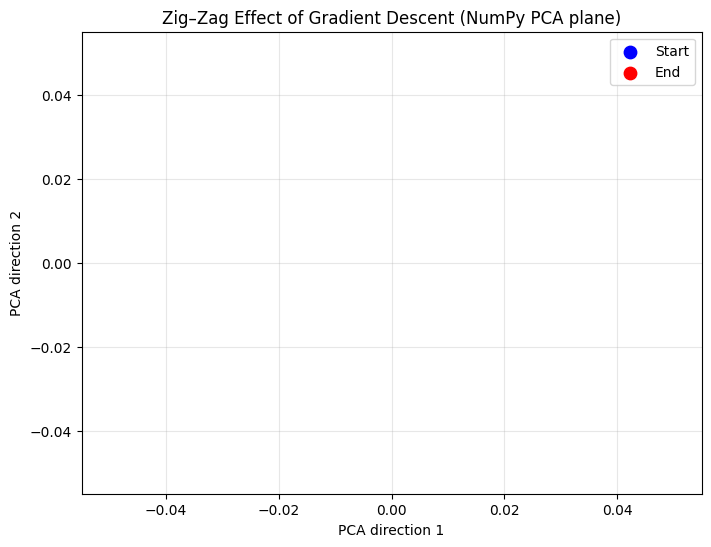

In [20]:
proj, components, mean_vec = pca_covariance(path, k=2)

plot_zigzag_contours_np_pca(
    X_train, y_train, lam=1.0,
    path=path,
    proj=proj,
    components=components,
    mean_vec=mean_vec
)

/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_99695/2382185530.py:31: RuntimeWarning: overflow encountered in matmul
  return 2 * (X.T @ (X @ w - y) + lam * w)
/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_99695/2382185530.py:31: RuntimeWarning: overflow encountered in multiply
  return 2 * (X.T @ (X @ w - y) + lam * w)
/var/folders/9x/mh1qldnn7yb23t560shhgzcc0000gn/T/ipykernel_99695/2382185530.py:31: RuntimeWarning: invalid value encountered in matmul
  return 2 * (X.T @ (X @ w - y) + lam * w)


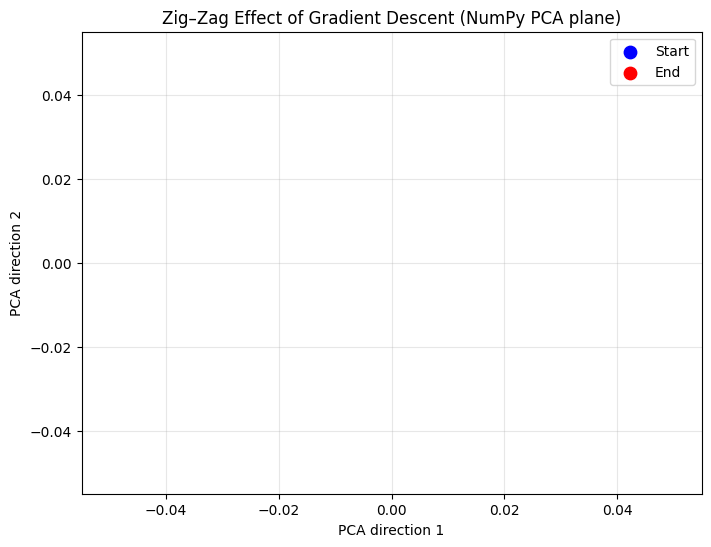

In [21]:
eta = 1e-3   # or 2e-3 for stronger zig-zag
w_final, path = gd_fixed_step_with_path(X_train, y_train, lam=1.0, eta=eta)

# 2. PCA on the path using robust covariance PCA
proj, components, mean_vec = pca_covariance(path, k=2)

# 3. Plot objective contours + zig-zag path in PCA plane
plot_zigzag_contours_np_pca(
    X_train, y_train, lam=1.0,
    path=path,
    proj=proj,
    components=components,
    mean_vec=mean_vec
)